In [21]:
from pathlib import Path
import sys
from time import time

# Allows the notebook to import files from the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
from src.preprocessing import load_csv, preprocess_data
from src.instantaneous_methods import velocity_magnitude_method
from src.interval_based_methods import (
    partition_data,
    partitioned_average_over_interval
)

In [23]:
file_path = PROJECT_ROOT / "data" / "LogAllData07-06_15-54-30.csv"

df = load_csv(file_path)
data = preprocess_data(df, do_savgol=True)

In [24]:
bucket_size = 5
VM = velocity_magnitude_method(data)
results = {
    "Velocity Magnitude": partition_data(data, VM[0], bucket_size=bucket_size),
}

Plotting

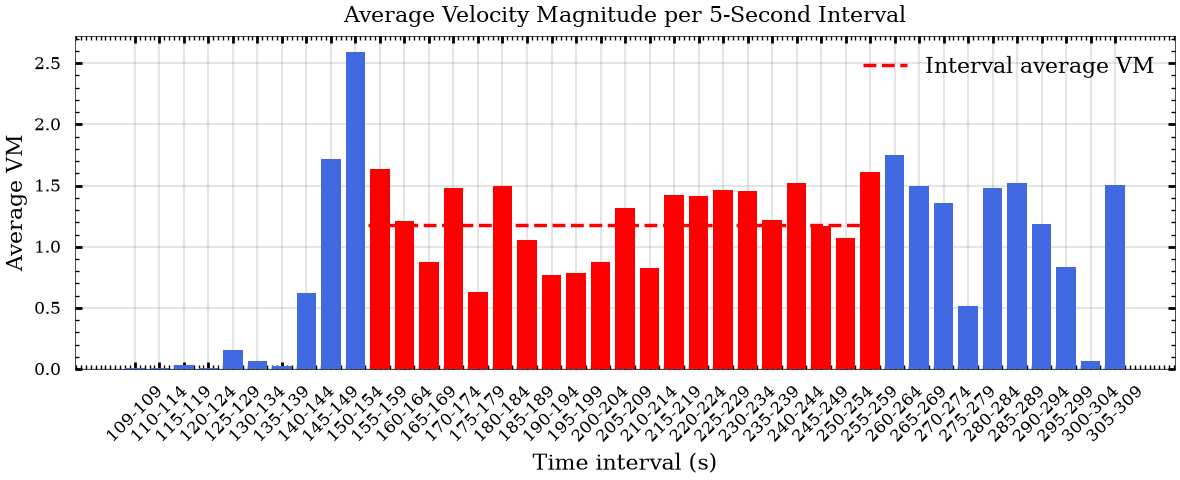

In [27]:
# Interval used to calculate the average VM
t_1 = data["time"].min() + 50.0
t_2 = t_1 + 100

# Interval displayed on the graph
plot_start_time = data["time"].min()
plot_end_time = plot_start_time + 200

time_min = data["time"].min()
time_max = data["time"].max()

# Validate calculation interval
if t_1 < time_min or t_2 > time_max or t_1 >= t_2:
    raise ValueError(
        "Calculation interval is invalid. Check that:"
        "\n\tt_1 >= min(time)"
        "\n\tt_2 <= max(time)"
        "\n\tt_1 < t_2"
    )

# Validate graph interval
if (
    plot_start_time < time_min
    or plot_end_time > time_max
    or plot_start_time >= plot_end_time
):
    raise ValueError(
        "Plot interval is invalid. Check that:"
        "\n\tplot_start_time >= min(time)"
        "\n\tplot_end_time <= max(time)"
        "\n\tplot_start_time < plot_end_time"
    )

df_5s = results["Velocity Magnitude"]

vm = velocity_magnitude_method(data)

interval_VM = partitioned_average_over_interval(
    data,
    vm[0],
    t_1,
    t_2,
)

with plt.style.context(["science", "notebook", "grid", plot_style]):

    labels = [
        f"{int(s)}-{int(e)}"
        for s, e in zip(df_5s["start_time"], df_5s["end_time"])
    ]

    # Buckets included in the calculation interval
    calculation_mask = (
        (df_5s["end_time"] >= t_1)
        & (df_5s["start_time"] <= t_2)
    )

    # Buckets shown on the graph
    plot_mask = (
        (df_5s["end_time"] >= plot_start_time)
        & (df_5s["start_time"] <= plot_end_time)
    )

    plot_df = df_5s.loc[plot_mask].copy()
    plot_labels = [
        f"{int(s)}-{int(e)}"
        for s, e in zip(plot_df["start_time"], plot_df["end_time"])
    ]

    colors = [
        "red" if is_in_interval else "royalblue"
        for is_in_interval in calculation_mask.loc[plot_df.index]
    ]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(
        plot_labels,
        plot_df["avg_VM"],
        color=colors
    )

    # Positions of the red bars within the displayed subset
    interval_positions = [
        i
        for i, is_in_interval in enumerate(
            calculation_mask.loc[plot_df.index]
        )
        if is_in_interval
    ]

    if interval_positions:
        ax.hlines(
            y=interval_VM,
            xmin=min(interval_positions) - 0.5,
            xmax=max(interval_positions) + 0.5,
            color="red",
            linestyle="--",
            linewidth=2.5,
            label="Interval average VM"
        )

    ax.set_xlabel("Time interval (s)")
    ax.set_ylabel("Average VM")
    ax.set_title(
        f"Average Velocity Magnitude per {bucket_size:g}-Second Interval"
    )

    ax.tick_params(axis="x", rotation=45)
    ax.legend()

    fig.tight_layout()
    plt.show()